# Day-ahead price regression — walk-forward backtest & diagrams

**Ingest:** `scripts/run_ingestion.py` also runs `deploy_regression_backtest` on the saved bundle and writes `data/processed/smard_bundle/regression_backtest.json` (metrics summary). If history is too short for `P_{t-168}`, the script prints a skip message.

This notebook runs the same **`deploy_regression_backtest`** pipeline and builds **tables**, **error bar charts**, and **prediction diagrams** (time series, scatter, error profiles).

- **Bundle:** `resolve_smard_bundle_dir(REPO_ROOT)` (primary `smard_bundle`, else `smard_bundle_qa_run`).
- **`use_synthetic_fallback=True`:** uses a temp synthetic bundle if the real slice is too short; set **`False`** for production-only.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path("..").resolve()
for p in (REPO_ROOT, REPO_ROOT / "src"):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

%matplotlib inline

from backtest.regression.pipeline import (
    deploy_regression_backtest,
    plot_actual_vs_predicted_scatter,
    plot_forecast_error_timeseries,
    plot_prediction_timeseries,
    resolve_smard_bundle_dir,
)

USE_SYNTHETIC_FALLBACK = True
N_EVAL_DAYS = 7
MIN_TRAIN_HOURS = 200

## Run pipeline (`deploy_regression_backtest`)

Returns `forecast_frame` (hourly actual vs each model), `overall_df`, `per_day_df`, `figure` (MAE/RMSE bars), and raw `result`.

Walk-forward day-ahead hourly backtest (UTC)
  bundle: /private/var/folders/y5/fnzcjs3j0w9fgc7mvy1fzg3h0000gn/T/regression_backtest_5eprli7k
  note (synthetic fallback was used): no usable regression rows: P_{t-168} needs >168 hours of aligned hourly data (price, residual load, hydro forecast). Re-fetch a longer SMARD slice.
  eval days completed: 3 (requested 3)
  forecast window: 2026-04-08T00:00:00+00:00 .. 2026-04-10T23:00:00+00:00
  model: day_ahead_price_eur_mwh ~ intercept + residual_load_mw, hydro_forecast_mw, price_lag_24, price_lag_168, h_1, h_2, h_3, h_4, h_5, h_6, h_7, h_8, h_9, h_10, h_11, h_12, h_13, h_14, h_15, h_16, h_17, h_18, h_19, h_20, h_21, h_22, h_23, dow_1, dow_2, dow_3, dow_4, dow_5, dow_6 (hour ref 0, dow ref Mon)

  regression              n=  72  MAE=6.7006  RMSE=7.8233
  naive_last              n=  72  MAE=10.4505  RMSE=12.7035
  naive_seasonal_24h      n=  72  MAE=8.7693  RMSE=10.6757
Fallback note: no usable regression rows: P_{t-168} needs >168 hours of a

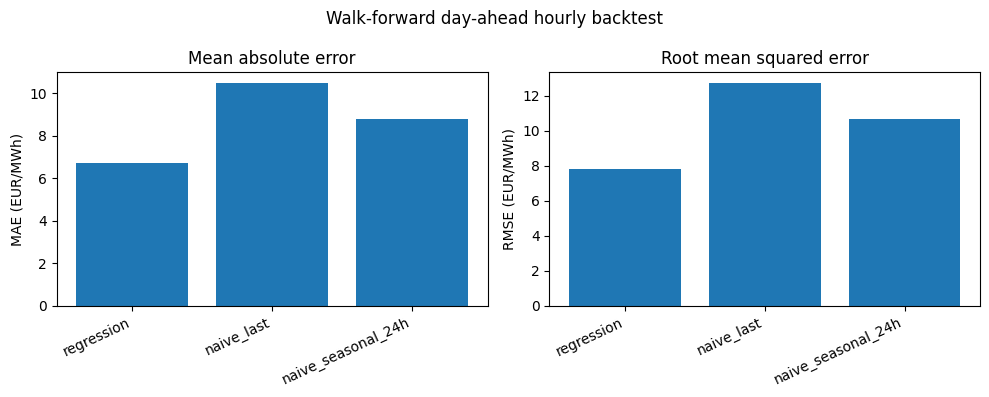

In [2]:
artifacts = deploy_regression_backtest(
    resolve_smard_bundle_dir(REPO_ROOT),
    n_eval_days=N_EVAL_DAYS,
    min_train_hours=MIN_TRAIN_HOURS,
    use_synthetic_fallback=USE_SYNTHETIC_FALLBACK,
    print_summary=True,
    json_path=None,
)

ff = artifacts["forecast_frame"]
if artifacts["fallback_note"]:
    print("Fallback note:", artifacts["fallback_note"])
print("Bundle used:", artifacts["bundle_dir_used"])
print("Forecast hours:", len(ff))

## Tables

In [3]:
display(artifacts["overall_df"])
display(artifacts["per_day_df"])
display(ff.head(12))

,n_hours,MAE,RMSE
model,,,
regression,72.0,6.7006,7.8233
naive_last,72.0,10.4505,12.7035
naive_seasonal_24h,72.0,8.7693,10.6757


,eval_date_utc,n_train_hours,regression_mae,regression_rmse,regression_n,naive_last_mae,naive_last_rmse,naive_last_n,naive_seasonal_24h_mae,naive_seasonal_24h_rmse,naive_seasonal_24h_n
0,2026-04-08,583,5.5535,6.4210,24,6.2505,7.8743,24,6.9397,8.7956,24
1,2026-04-09,607,7.6043,8.7026,24,15.5337,17.3819,24,8.4439,10.0905,24
2,2026-04-10,631,6.9440,8.1638,24,9.5673,10.9545,24,10.9241,12.7566,24


,actual,regression,naive_last,naive_seasonal_24h
2026-04-08 00:00:00+00:00,95.820989,90.043541,96.531621,86.148176
2026-04-08 01:00:00+00:00,86.387424,96.402914,96.531621,85.682174
2026-04-08 02:00:00+00:00,101.018210,93.872475,96.531621,82.115160
2026-04-08 03:00:00+00:00,103.533504,102.002161,96.531621,103.167752
2026-04-08 04:00:00+00:00,98.262951,87.111667,96.531621,94.427749
2026-04-08 05:00:00+00:00,110.321461,103.822416,96.531621,102.983462
2026-04-08 06:00:00+00:00,95.308311,99.727429,96.531621,105.315862
2026-04-08 07:00:00+00:00,103.510889,95.470567,96.531621,93.064438
2026-04-08 08:00:00+00:00,93.587280,94.210210,96.531621,91.065141
2026-04-08 09:00:00+00:00,81.659279,85.998759,96.531621,79.407568


## Diagram 1 — Overall MAE / RMSE (same as pipeline `figure`)

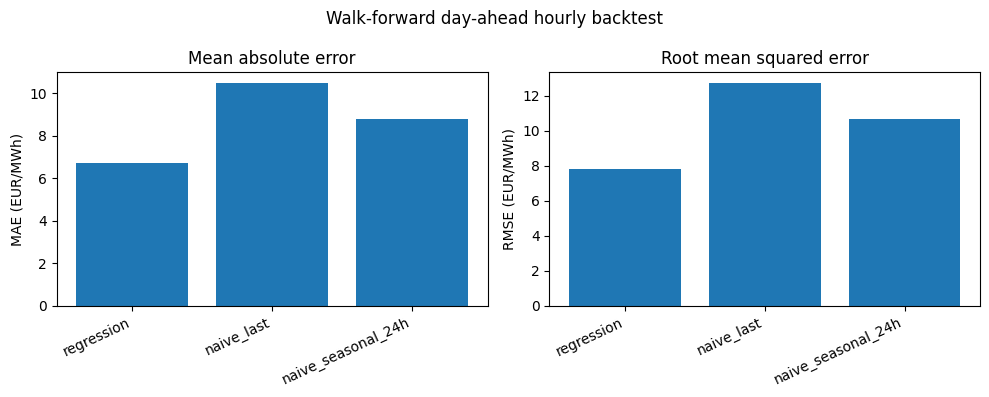

In [4]:
artifacts["figure"]

## Diagram 2 — Predictions vs actual (time series)

All walk-forward forecast hours: realized price and each model’s hourly prediction.

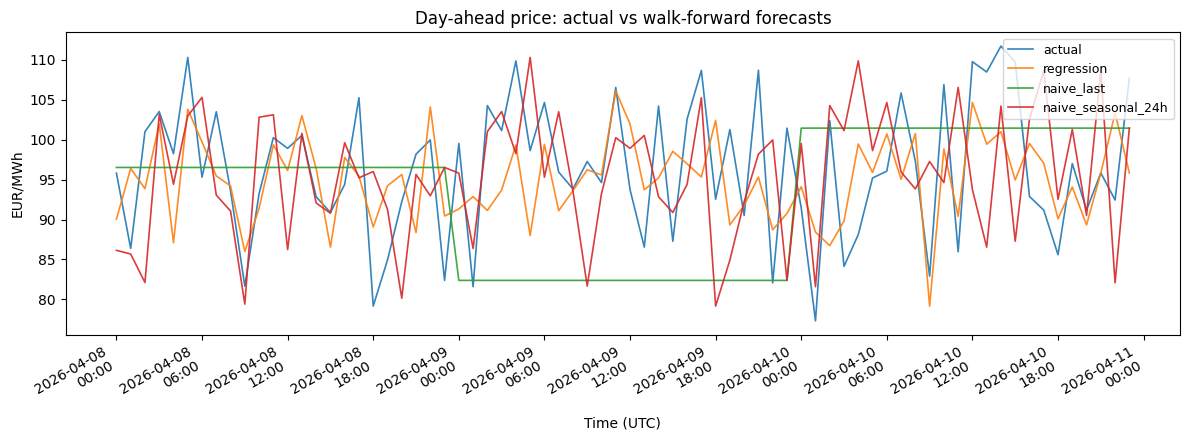

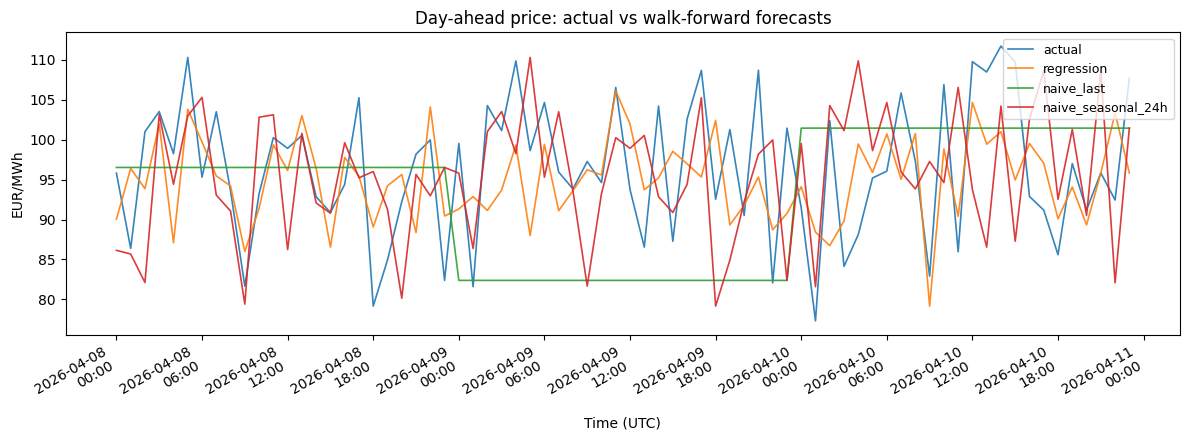

In [5]:
plot_prediction_timeseries(ff)

## Diagram 3 — Actual vs predicted (OLS regression)

Points should cluster near the diagonal if forecasts are well calibrated.

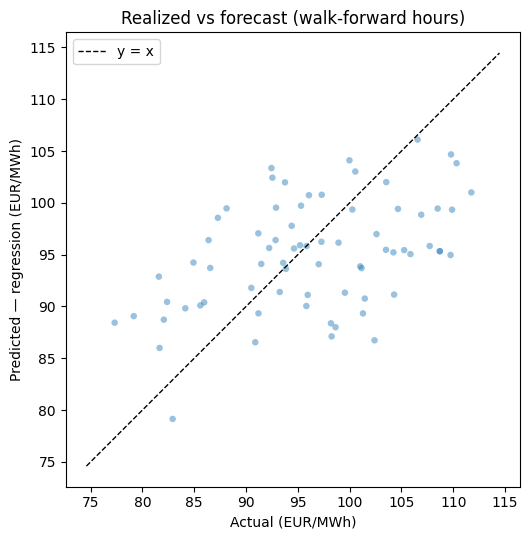

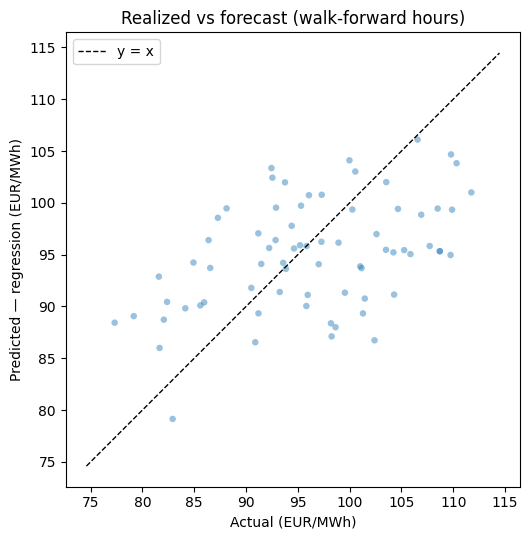

In [6]:
plot_actual_vs_predicted_scatter(ff, model_col="regression")

## Diagram 4 — Forecast errors over time

`actual − model` for regression and both naive baselines.

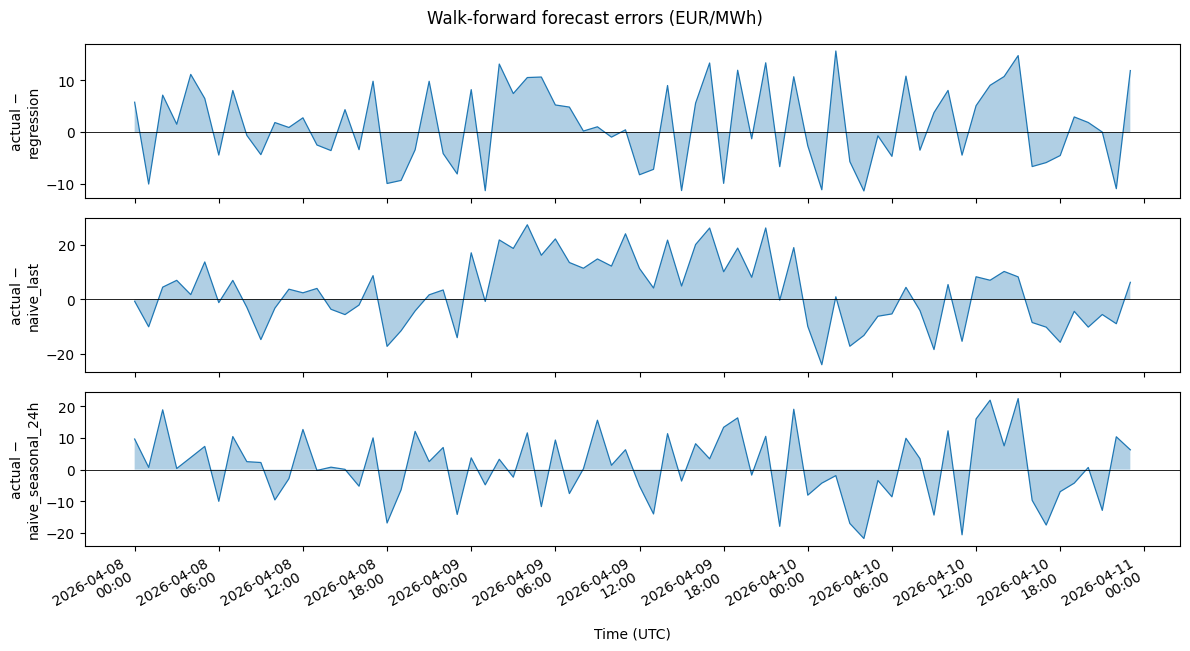

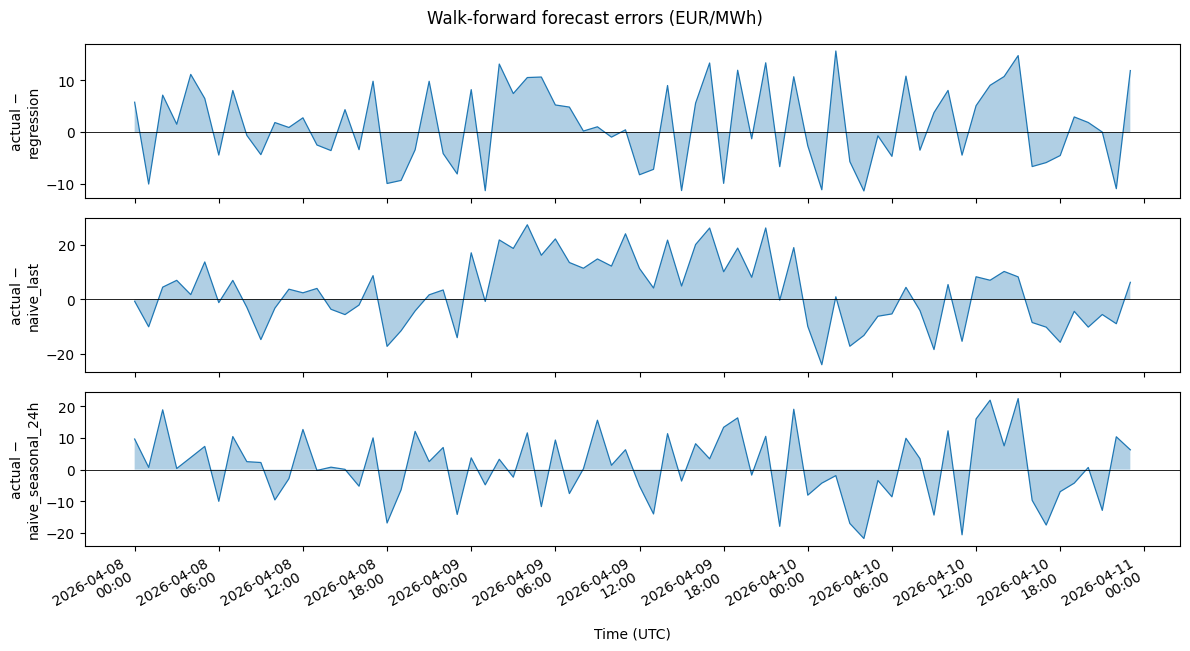

In [7]:
plot_forecast_error_timeseries(ff)

## Model specification (from raw result)

In [8]:
artifacts["result"]["spec"]

'day_ahead_price_eur_mwh ~ intercept + residual_load_mw, hydro_forecast_mw, price_lag_24, price_lag_168, h_1, h_2, h_3, h_4, h_5, h_6, h_7, h_8, h_9, h_10, h_11, h_12, h_13, h_14, h_15, h_16, h_17, h_18, h_19, h_20, h_21, h_22, h_23, dow_1, dow_2, dow_3, dow_4, dow_5, dow_6 (hour ref 0, dow ref Mon)'